# การพัฒนา Model โดยใช้ Python และ Software Package สำหรับผู้พัฒนา Model
## Module 6 - Regression (continued)
Asst. Prof. Dr. Santitham Prom-on

---

# 1. Load data

In [1]:
!wget -O mtcars.csv https://www.dropbox.com/scl/fi/n0e5sbzbc1sf90n4kr72h/mtcars.csv?rlkey=66jca705l0jnrj94eigxiwtpn&dl=1

--2024-09-04 07:33:26--  https://www.dropbox.com/scl/fi/n0e5sbzbc1sf90n4kr72h/mtcars.csv?rlkey=66jca705l0jnrj94eigxiwtpn
Resolving www.dropbox.com (www.dropbox.com)... 162.125.1.18, 2620:100:6016:18::a27d:112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.1.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc43c1af1760530bd4a5f878b34a.dl.dropboxusercontent.com/cd/0/inline/CZ66j2r8BylIi_pP48dJ4YVehnyyzCtz7bhkUilYWByMRuJ9GcQ03ktwJWTgcnW1U6kKgKA02FEXqm8Pl9CCgPFs1elCj6DZqGGuqQqL_4SvzE_pG3H37Eh-LyD6gAqHRAc/file# [following]
--2024-09-04 07:33:27--  https://uc43c1af1760530bd4a5f878b34a.dl.dropboxusercontent.com/cd/0/inline/CZ66j2r8BylIi_pP48dJ4YVehnyyzCtz7bhkUilYWByMRuJ9GcQ03ktwJWTgcnW1U6kKgKA02FEXqm8Pl9CCgPFs1elCj6DZqGGuqQqL_4SvzE_pG3H37Eh-LyD6gAqHRAc/file
Resolving uc43c1af1760530bd4a5f878b34a.dl.dropboxusercontent.com (uc43c1af1760530bd4a5f878b34a.dl.dropboxusercontent.com)... 162.125.1.15, 2620:100:6016:15::a27d:10f
Connecting to uc43c1af1

In [ ]:
import pandas as pd

mtcars = pd.read_csv('mtcars.csv', index_col=0)
mtcars.head()

# 2. Assess correlations between variables

### As a correlation matrix

In [ ]:
mtcars.corr()

### As a heatmap

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(font_scale=1.2)

In [ ]:
sns.clustermap(mtcars.corr(), cmap='RdYlBu', vmin=-1, vmax=1)
plt.show()

# 3. Visualize a linear relationship as a scatterplot

### Negative relationship

In [ ]:
c = mtcars['mpg'].corr(mtcars['wt'])
print("Correlation = %0.2f"%mtcars['mpg'].corr(mtcars['wt']))
sns.regplot(data=mtcars, x='wt', y='mpg')
plt.show()

### Positive relationship

In [ ]:
c = mtcars['hp'].corr(mtcars['disp'])
print("Correlation = %0.2f"%mtcars['hp'].corr(mtcars['disp']))
sns.regplot(data=mtcars, x='hp', y='disp')
plt.show()

### No relationship

In [ ]:
c = mtcars['qsec'].corr(mtcars['drat'])
print("Correlation = %0.2f"%mtcars['qsec'].corr(mtcars['drat']))
sns.regplot(data=mtcars, x='qsec', y='drat')
plt.show()

# 4. Linear regression

### with statmodels

In [ ]:
from statsmodels.formula.api import ols

model = ols('mpg ~ wt',mtcars).fit()
model.summary()

In [ ]:
model.predict(mtcars)

### with sci-kit learn

In [ ]:
X = mtcars.drop(columns='mpg')
y = mtcars['mpg']

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_df = pd.DataFrame(scaler.fit_transform(X), columns = X.columns)

In [ ]:
X_df

In [ ]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm.fit(X_df,y)

In [ ]:
from sklearn.metrics import r2_score
r2_score(y_pred=lm.predict(X_df), y_true=y)

In [ ]:
pd.DataFrame(dict(Feature = X_df.columns,
                  Coefficient = lm.coef_))

# 5. Poisson regression


In [2]:
!wget -O mines.csv https://www.dropbox.com/scl/fi/y5wi9iqgyxjiwm4stdbx3/mines.csv?rlkey=t04s3l1ynyhr3moknm5y55ej8&dl=0

--2024-09-04 07:33:27--  https://www.dropbox.com/scl/fi/y5wi9iqgyxjiwm4stdbx3/mines.csv?rlkey=t04s3l1ynyhr3moknm5y55ej8
Resolving www.dropbox.com (www.dropbox.com)... 162.125.1.18, 2620:100:6016:18::a27d:112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.1.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uccc55bc458ebc0ed2ebf92852b1.dl.dropboxusercontent.com/cd/0/inline/CZ6q6q2ixCSPxoh4eGwtDMy7CuqNYOj7WUt461x5YRbFCXVM4y2dM91n2XUbYLGVYu5fNEqnR05XIlwUvUUu0RyB_mUxuPxYF6EVbjCQoUqI1UB2AJojLUciAiwj01D_fko/file# [following]
--2024-09-04 07:33:28--  https://uccc55bc458ebc0ed2ebf92852b1.dl.dropboxusercontent.com/cd/0/inline/CZ6q6q2ixCSPxoh4eGwtDMy7CuqNYOj7WUt461x5YRbFCXVM4y2dM91n2XUbYLGVYu5fNEqnR05XIlwUvUUu0RyB_mUxuPxYF6EVbjCQoUqI1UB2AJojLUciAiwj01D_fko/file
Resolving uccc55bc458ebc0ed2ebf92852b1.dl.dropboxusercontent.com (uccc55bc458ebc0ed2ebf92852b1.dl.dropboxusercontent.com)... 162.125.1.15, 2620:100:6016:15::a27d:10f
Connecting to uccc55bc45

In [3]:
import pandas as pd
mines = pd.read_csv('mines.csv')
mines.head()

,COUNT,INB,EXTRP,AHS,AGE
0,2,50,70,52,1.0
1,1,230,65,42,6.0
2,0,125,70,45,1.0
3,4,75,65,68,0.5
4,1,70,65,53,0.5


# 6. Visualize data distribution

<Axes: >

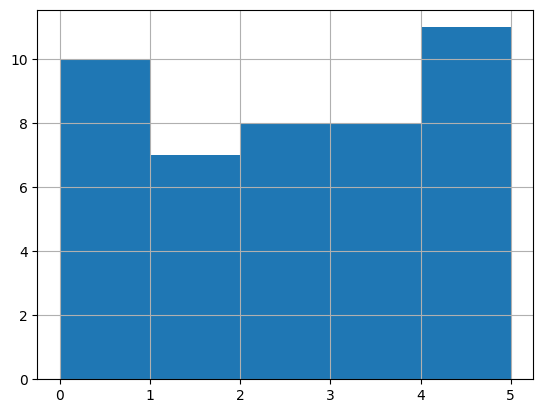

In [4]:
mines['COUNT'].hist(bins=5)

In [ ]:
import seaborn as sns
sns.histplot(mines['COUNT'])

# 7. Poisson regression

### with statmodels

In [5]:
import statsmodels.api as sm
from statsmodels.genmod.families import Poisson

In [6]:
X = mines.drop(columns='COUNT')
X_prep = sm.add_constant(X)
y = mines['COUNT']
model = sm.GLM(y, X_prep, family = Poisson()).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  COUNT   No. Observations:                   44
Model:                            GLM   Df Residuals:                       39
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -66.995
Date:                Wed, 04 Sep 2024   Deviance:                       37.717
Time:                        07:34:17   Pearson chi2:                     35.8
No. Iterations:                     5   Pseudo R-squ. (CS):             0.5713
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.6097      1.028     -3.510      0.000      -5.625      -1.594
INB           -0.0014      0.001     -1.716      0.086      -0.003       0.000
EXTRP          0.0622      0.012      5.062      0.000       0.038       0.086
AHS           -0.0018      0.005     -0.346      0.729      -0.012       0.008
AGE           -0.0296      0.016     -1.816      0.069      -0.062       0.002
==============================================================================
"""

In [7]:
y_res = model.predict(X_prep)

In [8]:
from sklearn.metrics import mean_absolute_error

mean_absolute_error(y_true=y, y_pred=y_res)

0.9307388957080918

### Evaluation

In [9]:
from sklearn.metrics import mean_absolute_error

In [10]:
mean_absolute_error(y_pred=model.predict(X_prep), y_true=y)

0.9307388957080918

In [11]:
sns.scatterplot(x=y, y=model.predict(X_prep))

NameError: name 'sns' is not defined

# Compare to linear regression

MAE of Poisson Regression = 0.9307

In [12]:
X_prep = sm.add_constant(X)
lm = sm.OLS(y, X_prep).fit()
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  COUNT   R-squared:                       0.530
Model:                            OLS   Adj. R-squared:                  0.482
Method:                 Least Squares   F-statistic:                     11.00
Date:                Wed, 04 Sep 2024   Prob (F-statistic):           4.55e-06
Time:                        07:38:20   Log-Likelihood:                -69.941
No. Observations:                  44   AIC:                             149.9
Df Residuals:                      39   BIC:                             158.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.5797      1.379     -3.321      0.002      -7.369      -1.790
INB           -0.0020      0.001     -1.524      0.136      -0.005       0.001
EXTRP          0.1042      0.017      6.119      0.000       0.070       0.139
AHS           -0.0077      0.009     -0.901      0.373      -0.025       0.010
AGE           -0.0486      0.028     -1.725      0.092      -0.106       0.008
==============================================================================
Omnibus:                        1.311   Durbin-Watson:                   2.526
Prob(Omnibus):                  0.519   Jarque-Bera (JB):                1.056
Skew:                           0.375   Prob(JB):                        0.590
Kurtosis:                       2.877   Cond. No.                     1.77e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.77e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [13]:
y_res = lm.predict(X_prep)
mean_absolute_error(y, y_res)

0.9366988953509331

In [14]:
y_res

,0
0,2.170637
1,1.128059
2,2.076445
3,1.501468
4,1.626576
5,2.089919
6,1.021765
7,0.545242
8,3.672588
9,3.152231


<Axes: >

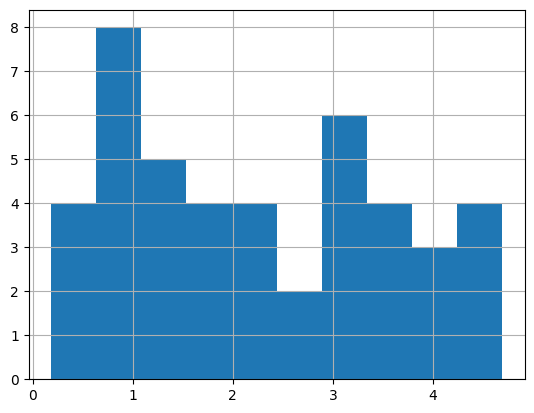

In [15]:
model.predict(X_prep).hist()

<Axes: >

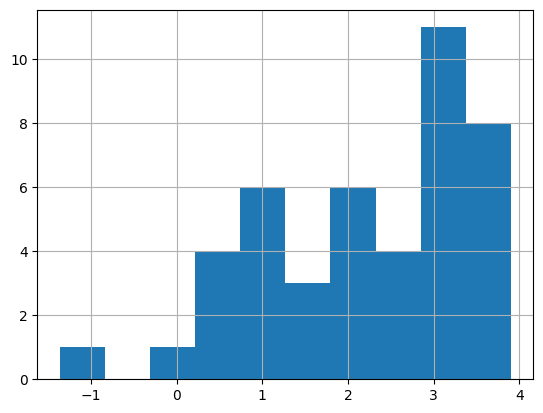

In [16]:
lm.predict(X_prep).hist()

# Activity
Use the cancer.xls data and perform Poisson regression analysis

In [ ]:
!wget -O cancer.xls https://www.dropbox.com/scl/fi/liwhrsk2voczh7jmajrts/cancer.xls?rlkey=ws3yj709k279k7qaj9iixjw23&dl=0

In [ ]:
# work here
cancer = pd.read_excel('cancer.xls', sheet_name='Sheet2',
                       index_col='index')
cancer.head()

In [ ]:
cancer['dead'].hist()

In [ ]:
cancer['smoke'].value_counts()

In [ ]:
cancer.replace({'smoke':{'no':'0_no'}}, inplace=True)

In [ ]:
cancer_cat = pd.get_dummies(cancer[['age','smoke']], drop_first=True)
cancer_cat.head()

In [ ]:
cancer_prep = pd.concat([cancer_cat,cancer['pop']], axis=1)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
cancer_prep_1 = pd.DataFrame(mms.fit_transform(cancer_prep), columns=cancer_prep.columns)
cancer_prep_1.head()

In [ ]:
cancer['dead']

In [ ]:
model = sm.GLM(cancer['dead'].reset_index(drop=True),
               sm.add_constant(cancer_prep_1),
               family = Poisson()).fit()
model.summary()

In [ ]:
model.predict(sm.add_constant(cancer_prep_1))

# 8. Survival analysis

For this example, we will be investigating the lifetimes of political leaders around the world. A political leader, in this case, is defined by a single individual’s time in office who controls the ruling regime. This political leader could be an elected president, unelected dictator, monarch, etc. The birth event is the start of the individual’s tenure, and the death event is the retirement of the individual. Censoring can occur if they are a) still in offices at the time of dataset compilation (2008), or b) die while in power (this includes assassinations).

For example, the Bush regime began in 2000 and officially ended in 2008 upon his retirement, thus this regime’s lifespan was eight years, and there was a “death” event observed. On the other hand, the JFK regime lasted 2 years, from 1961 and 1963, and the regime’s official death event was not observed – JFK died before his official retirement.

In [17]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.5/94.5 kB 5.0 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4031 sha256=ab7c0acf9d53a4f22cb1647c4a940888fd06e6a1b53876b4525af55c7797d699
  Stored in directory: /root/.cache/pip/wheels/25/cc/e0/ef2969164144c899fedb22b338f6703e2b9cf46eeebf254991
Successfully built autograd-gamma


In [18]:
from lifelines.datasets import load_dd

data = load_dd()
data.head()

,ctryname,cowcode2,politycode,un_region_name,un_continent_name,ehead,leaderspellreg,democracy,regime,start_year,duration,observed
0,Afghanistan,700,700.0,Southern Asia,Asia,Mohammad Zahir Shah,Mohammad Zahir Shah.Afghanistan.1946.1952.Mona...,Non-democracy,Monarchy,1946,7,1
1,Afghanistan,700,700.0,Southern Asia,Asia,Sardar Mohammad Daoud,Sardar Mohammad Daoud.Afghanistan.1953.1962.Ci...,Non-democracy,Civilian Dict,1953,10,1
2,Afghanistan,700,700.0,Southern Asia,Asia,Mohammad Zahir Shah,Mohammad Zahir Shah.Afghanistan.1963.1972.Mona...,Non-democracy,Monarchy,1963,10,1
3,Afghanistan,700,700.0,Southern Asia,Asia,Sardar Mohammad Daoud,Sardar Mohammad Daoud.Afghanistan.1973.1977.Ci...,Non-democracy,Civilian Dict,1973,5,0
4,Afghanistan,700,700.0,Southern Asia,Asia,Nur Mohammad Taraki,Nur Mohammad Taraki.Afghanistan.1978.1978.Civi...,Non-democracy,Civilian Dict,1978,1,0


In [19]:
data.shape

(1808, 12)

Let's take a look at our country.

In [20]:
data[data['ctryname'] == 'Thailand']

,ctryname,cowcode2,politycode,un_region_name,un_continent_name,ehead,leaderspellreg,democracy,regime,start_year,duration,observed
1602,Thailand,800,800.0,South-Eastern Asia,Asia,Luang Thamrongnawasawat,Luang Thamrongnawasawat.Thailand.1946.1946.Mil...,Non-democracy,Military Dict,1946,1,1
1603,Thailand,800,800.0,South-Eastern Asia,Asia,Luang Phibulsongkhram,Luang Phibulsongkhram.Thailand.1947.1956.Milit...,Non-democracy,Military Dict,1947,10,1
1604,Thailand,800,800.0,South-Eastern Asia,Asia,Thanom Kittikachorn,Thanom Kittikachorn.Thailand.1957.1957.Militar...,Non-democracy,Military Dict,1957,1,1
1605,Thailand,800,800.0,South-Eastern Asia,Asia,Sarit Thanarat,Sarit Thanarat.Thailand.1958.1962.Military Dict,Non-democracy,Military Dict,1958,5,0
1606,Thailand,800,800.0,South-Eastern Asia,Asia,Thanom Kittikachorn,Thanom Kittikachorn.Thailand.1963.1972.Militar...,Non-democracy,Military Dict,1963,10,1
1607,Thailand,800,800.0,South-Eastern Asia,Asia,Sanya Thammasak,Sanya Thammasak.Thailand.1973.1974.Civilian Dict,Non-democracy,Civilian Dict,1973,2,1
1608,Thailand,800,800.0,South-Eastern Asia,Asia,Kukrit Pramoj,Kukrit Pramoj.Thailand.1975.1975.Parliamentary...,Democracy,Parliamentary Dem,1975,1,1
1609,Thailand,800,800.0,South-Eastern Asia,Asia,military,military.Thailand.1976.1976.Military Dict,Non-democracy,Military Dict,1976,1,1
1610,Thailand,800,800.0,South-Eastern Asia,Asia,Kriangsak Chamanand,Kriangsak Chamanand.Thailand.1977.1978.Militar...,Non-democracy,Military Dict,1977,2,1
1611,Thailand,800,800.0,South-Eastern Asia,Asia,Kriangsak Chamanand,Kriangsak Chamanand.Thailand.1979.1979.Parliam...,Democracy,Parliamentary Dem,1979,1,1


In [21]:
from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()

T = data["duration"]
E = data["observed"]

kmf.fit(T, event_observed=E)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 1808 total observations, 340 right-censored observations>

In [22]:
kmf.survival_function_at_times(10)

,KM_estimate
10,0.18135


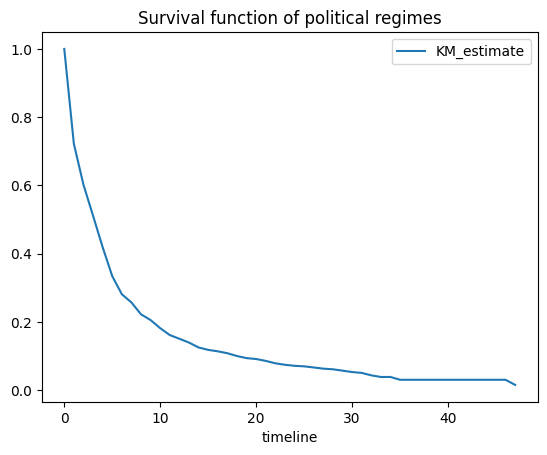

In [23]:
import matplotlib.pyplot as plt
kmf.survival_function_.plot()
plt.title('Survival function of political regimes');

How do we interpret this? The y-axis represents the probability a leader is still around after 𝑡
t
 years, where 𝑡
t
 years is on the x-axis. We see that very few leaders make it past 20 years in office.

<Axes: xlabel='timeline'>

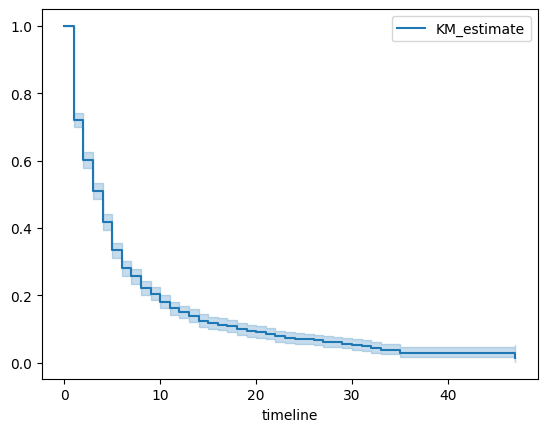

In [24]:
kmf.plot()

The median time in office, which defines the point in time where on average 1/2 of the population has expired, is a property:

In [25]:
kmf.median_survival_time_

4.0

Interesting that it is only four years. That means, around the world, elected leaders have a 50% chance of cessation in four years or less!

## Plot by segment (regimes)

Let’s segment on democratic regimes vs non-democratic regimes. Calling plot on either the estimate itself or the fitter object will return an axis object, that can be used for plotting further estimates:

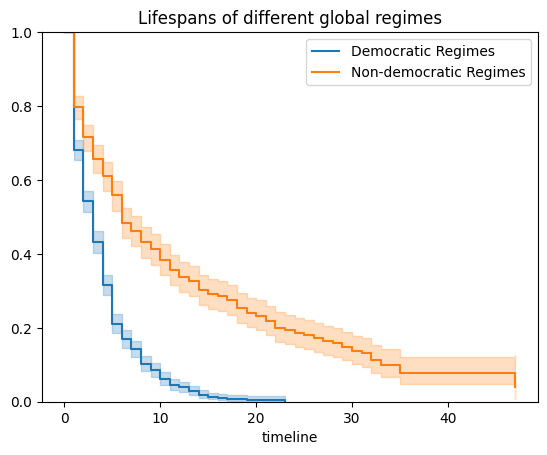

In [26]:
ax = plt.subplot(111)

dem = (data["democracy"] == "Democracy")

kmf.fit(T[dem], event_observed=E[dem], label="Democratic Regimes")
kmf.plot(ax=ax)
kmf.fit(T[~dem], event_observed=E[~dem], label="Non-democratic Regimes")
kmf.plot(ax=ax)

plt.ylim(0, 1);
plt.title("Lifespans of different global regimes");

# Mathematical Notations

## Survival function

We will assume for now that T is a continuous random variable with probability density function (p.d.f.) $$f(t)$$ and cumulative distribution function (c.d.f.) $$F(t)=Pr(T<t),$$ giving the probability that the event has occurred by duration t.

$$S(t) = \Pr\{ T \ge t \} = 1 - F(t) =  \int_t^\infty f(x) dx,$$

## Hazard function

An alternative characterization of the distribution of T
 is given by the hazard function, or instantaneous rate of occurrence of the event, defined as

$$\lambda(t) = \lim_{dt\rightarrow0} \frac{\Pr\{t \le T < t + dt |
T \ge t \} }{dt}.$$

# 9. Cox’s proportional hazard model

The idea behind Cox’s proportional hazard model model is that the log-hazard of an individual is a linear function of their static covariates and a population-level baseline hazard that changes over time. Mathematically:

$$\underbrace{h(t | x)}_{\text{hazard}} = \overbrace{b_0(t)}^{\text{baseline hazard}} \underbrace{\exp \overbrace{\left(\sum_{i=1}^n b_i (x_i - \overline{x_i})\right)}^{\text{log-partial hazard}}}_ {\text{partial hazard}}$$

In [ ]:
from lifelines import CoxPHFitter
from lifelines.datasets import load_rossi

rossi_dataset = load_rossi()
rossi_dataset.head()

This data set is originally from Rossi et al. (1980), and is used as an example in Allison (1995). The data pertain to 432 convicts who were released from Maryland state prisons in the 1970s and who were followed up for one year after release. Half the released convicts were assigned at random to an experimental treatment in which they were given financial aid; half did not receive aid.

- week: week of first arrest after release or censoring; all censored observations are censored at 52 weeks.
- arrest: 1 if arrested, 0 if not arrested.
- fin: financial aid: no yes.
- age: in years at time of release.
- race: black or other.
- wexp: full-time work experience before incarceration: no or yes.
- mar: marital status at time of release: married or not married.
- paro: released on parole? no or yes.
- prio: number of convictions prior to current incarceration.

In [ ]:
cph = CoxPHFitter()
cph.fit(rossi_dataset, duration_col='week', event_col='arrest', show_progress=True)

cph.print_summary()

In [ ]:
cph.plot()

In [ ]:
X = rossi_dataset

plt.plot(cph.predict_survival_function(X[0:1]))

# Activity - Estimating Lifetime
- Use Telco Churn dataset and build a Kaplan Meier survival analysis.
- Compare lifetime between different payment methods.

In [ ]:
# work